# PHYT1D — File 2: Patient Data, MCMC Identification & 24h Trajectory

**Run File 1 first:** `%run phyt1d_functions.ipynb`

**Contents:**
1. Patient CSV import
2. Fixed + user parameters
3. Ground-truth from patient CGM
4. MCMC Window A — identify θ_A
5. MCMC Window B — identify θ_B
6. Ensemble simulation (rest — no exercise)
7. Evaluation metrics
8. 24h glucose plot with uncertainty bands


In [11]:
# ── Import all functions from File 1 ─────────────────────────────────────────
%run phyt1d_functions.ipynb

PHYT1D Functions Library — v2.0
✓ estimate_VO2max defined
✓ FIXED parameters (Group D) loaded
✓ build_rates defined
✓ simulate_trajectory_main defined
✓ log_prior_A_main defined
✓ log_likelihood_main defined
✓ run_MCMC_A_main defined
✓ log_prior_B_main defined
✓ run_MCMC_B_main defined
✓ draw_posterior_samples defined
✓ run_ensemble defined
✓ MARD_fn, RMSE_fn, TIR_fn, print_eval_report defined

✓ ALL PHYT1D FUNCTIONS LOADED SUCCESSFULLY
  Import into other notebooks with:  %run phyt1d_functions.ipynb


## Step 0 — Patient CSV Import

In [12]:
import pandas as pd

# ════════════════════════════════════════════════════
# ← CHANGE THIS PATH TO YOUR patient_data.csv FILE
CSV_PATH = r"...\data\Example_data.csv"
# ════════════════════════════════════════════════════

df = pd.read_csv(CSV_PATH)

required_cols = {"time_min", "cgm_mgdl", "insulin_U", "cho_g"}
missing = required_cols - set(df.columns)
if missing:
    raise ValueError(f"CSV missing columns: {missing}")

df = df.sort_values("time_min").reset_index(drop=True).fillna(0.0)

cgm_times = df["time_min"].values.astype(float)
cgm_obs   = df["cgm_mgdl"].values.astype(float)
insulin_U = df["insulin_U"].values.astype(float)
cho_g     = df["cho_g"].values.astype(float)

# Gb from fasting window (first 60 min, no meal, no bolus)
fasting_mask = (cgm_times <= 60) & (cho_g == 0) & (insulin_U == 0)
Gb_data = float(np.median(cgm_obs[fasting_mask]))           if fasting_mask.sum() > 3 else 120.0

bolus_mask  = insulin_U > 0.5
bolus_total = insulin_U[bolus_mask].sum()
basal_total = insulin_U[~bolus_mask].sum()

print(f"✓ Patient CSV loaded: {len(df)} rows")
print(f"  Time range  : {cgm_times[0]:.0f}–{cgm_times[-1]:.0f} min")
print(f"  CGM range   : {cgm_obs.min():.1f}–{cgm_obs.max():.1f} mg/dL")
print(f"  Gb (fasting): {Gb_data:.1f} mg/dL")
print(f"  Total bolus : {bolus_total:.2f} U")
print(f"  Total meals : {cho_g.sum():.0f} g CHO")


✓ Patient CSV loaded: 289 rows
  Time range  : 0–1440 min
  CGM range   : 102.3–190.5 mg/dL
  Gb (fasting): 120.0 mg/dL
  Total bolus : 14.33 U
  Total meals : 215 g CHO


## Step 1 — User Parameters (Group C)

In [13]:
def default_user_params():
    return {
        # Exercise — set u=0, d=0 for rest patient
        "u": 0.0, "d": 0.0, "t_start": 420.0, "exercise_type": "aerobic",
        # Insulin
        "CR": 15.0,
        # Meals (defaults — overridden from CSV below)
        "CHO_BF": 45.0, "CHO_LU": 70.0, "CHO_DN": 60.0, "CHO_SN": 20.0,
        "t_BF": 60.0, "t_LU": 300.0, "t_DN": 780.0, "t_SN": 960.0,
        # Modulation factors (nominal = 1.0)
        "bolus_factor": 1.0, "CHO_factor": 1.0,
        # Demographics
        "sex": "M", "age_group": "adult",
        # Basal insulin rate (U/h) — continuous background
        "basal_rate": 0.35,
    }

USER_PARAMS = default_user_params()
print("✓ Default Group C parameters loaded")


✓ Default Group C parameters loaded


## Step 2 — VO2max Prior

In [14]:
vo2_prior_mean = estimate_VO2max(USER_PARAMS["age_group"], USER_PARAMS["sex"])
vo2_prior_std  = 8.0
print(f"✓ VO2max prior: N({vo2_prior_mean:.1f}, {vo2_prior_std}²) mL/kg/min")


✓ VO2max prior: N(45.2, 8.0²) mL/kg/min


## Step 3 — Build Ground-Truth and USER_PARAMS from CSV

In [15]:
# Interpolate patient CGM onto uniform 5-min simulation grid
times_true = np.arange(0, 1441, 5, dtype=float)
ig_true    = np.interp(times_true, cgm_times, cgm_obs)
times_h    = times_true / 60

# Detect meals chronologically from CSV
meal_events = sorted(
    [(cgm_times[i], cho_g[i]) for i in range(len(cgm_times)) if cho_g[i] > 5.0],
    key=lambda x: x[0]
)
slot_names = ["BF", "LU", "DN", "SN"]
meal_slots = {"BF":(60,45.), "LU":(300,70.), "DN":(780,60.), "SN":(960,20.)}
for i, (t_meal, cho) in enumerate(meal_events[:4]):
    meal_slots[slot_names[i]] = (t_meal, cho)

# Estimate CR from largest meal-bolus pair
bolus_events = [(cgm_times[i], insulin_U[i])
                for i in range(len(cgm_times)) if insulin_U[i] > 0.5]
CR_data = 15.0
if bolus_events and meal_events:
    lm_t, lm_cho = max(meal_events, key=lambda x: x[1])
    cb = min(bolus_events, key=lambda b: abs(b[0] - lm_t))
    if cb[1] > 0:
        CR_data = float(np.clip(round(lm_cho / cb[1], 1), 5.0, 30.0))

USER_PARAMS.update({
    "CR"    : CR_data,
    "CHO_BF": meal_slots["BF"][1], "t_BF": meal_slots["BF"][0],
    "CHO_LU": meal_slots["LU"][1], "t_LU": meal_slots["LU"][0],
    "CHO_DN": meal_slots["DN"][1], "t_DN": meal_slots["DN"][0],
    "CHO_SN": meal_slots["SN"][1], "t_SN": meal_slots["SN"][0],
    "Gb"    : Gb_data,
})

# Initial parameter values
THETA_A_TRUE = {
    "SI": np.exp(-5.3), "SG": 0.025, "Gb": Gb_data,
    "p2": 0.025, "kd": 0.026, "ka2": 0.066,
    "kempt": 0.055, "kabs": 0.057,
}
THETA_B_TRUE = {
    "beta_aer": 0.50, "beta_res": 0.30, "tau_post": 240.0,
    "tau_on": 15.0, "VO2max": vo2_prior_mean, "phi": 0.1,
}
THETA_A_TRUE["Gb"] = Gb_data

print(f"✓ Patient data prepared")
print(f"  Gb={Gb_data:.1f} mg/dL   CR={CR_data:.1f} g/U")
print(f"  Meals:")
for slot, (t, cho) in meal_slots.items():
    print(f"    {slot}: {cho:.0f}g at t={t:.0f} min ({t/60:.1f}h)")
print(f"  IG trace: {len(ig_true)} pts  "
      f"mean={ig_true.mean():.1f}  "
      f"TIR={np.sum((ig_true>=70)&(ig_true<=180))/len(ig_true)*100:.1f}%")


✓ Patient data prepared
  Gb=120.0 mg/dL   CR=15.0 g/U
  Meals:
    BF: 45g at t=60 min (1.0h)
    LU: 70g at t=300 min (5.0h)
    DN: 80g at t=780 min (13.0h)
    SN: 20g at t=960 min (16.0h)
  IG trace: 289 pts  mean=129.1  TIR=97.6%


## Step 4 — MCMC Window A: Identify θ_A

In [16]:
# Window A: full day, excluding 15-min bolus spikes around each meal
meal_times = [USER_PARAMS["t_BF"], USER_PARAMS["t_LU"],
              USER_PARAMS["t_DN"], USER_PARAMS["t_SN"]]
spike_mask = np.zeros(len(times_true), dtype=bool)
for tm in meal_times:
    spike_mask |= (times_true >= tm) & (times_true <= tm + 15)

win_A_mask = ~spike_mask
cgm_wA     = ig_true[win_A_mask]
times_wA   = times_true[win_A_mask]
user_noex  = USER_PARAMS.copy(); user_noex["u"] = 0.0  # no exercise for Window A

print(f"Window A: {win_A_mask.sum()} CGM points across full day")

THETA_A_INIT = {"SI": np.exp(-5.3), "SG": 0.025, "Gb": Gb_data,
                "p2": 0.025, "kd": 0.026, "ka2": 0.066,
                "kempt": 0.055, "kabs": 0.057}
THETA_B_INIT = {"beta_aer": 0.50, "beta_res": 0.30, "tau_post": 240.0,
                "tau_on": 15.0, "VO2max": vo2_prior_mean, "phi": 0.1}

print("\nRunning MCMC Window A (2000 iterations)...")
chain_A = run_MCMC_A_main(THETA_A_INIT, THETA_B_INIT, cgm_wA, times_wA,
                           user_noex, FIXED, n_samples=2000, burn_in=1000)
THETA_A_MED = {k: np.median([s[k] for s in chain_A]) for k in chain_A[0]}

print("\n✓ Window A complete. Posterior medians:")
for k, v in THETA_A_MED.items():
    true_v = THETA_A_TRUE[k]
    re = abs(v - true_v) / abs(true_v) * 100
    print(f"  {k:8s}  est={v:.5f}  init={true_v:.5f}  RE={re:.1f}%")

Window A: 273 CGM points across full day

Running MCMC Window A (2000 iterations)...
  Window A    200/2000  accept=0.47  lp=-988.9
  Window A    400/2000  accept=0.45  lp=-978.8
  Window A    600/2000  accept=0.43  lp=-979.6
  Window A    800/2000  accept=0.41  lp=-980.6
  Window A   1000/2000  accept=0.39  lp=-975.6
  Window A   1200/2000  accept=0.38  lp=-975.8
  Window A   1400/2000  accept=0.37  lp=-975.5
  Window A   1600/2000  accept=0.36  lp=-976.6
  Window A   1800/2000  accept=0.36  lp=-977.1
  Window A   2000/2000  accept=0.35  lp=-978.0


✓ Window A complete. Posterior medians:
  SI        est=0.00028  init=0.00499  RE=94.3%
  SG        est=0.04950  init=0.02500  RE=98.0%
  Gb        est=130.59546  init=120.03000  RE=8.8%
  p2        est=0.04017  init=0.02500  RE=60.7%
  kd        est=0.03984  init=0.02600  RE=53.2%
  ka2       est=0.05008  init=0.06600  RE=24.1%
  kempt     est=0.02680  init=0.05500  RE=51.3%
  kabs      est=0.18511  init=0.05700  RE=224.8%


## Step 5 — MCMC Window B: Identify θ_B

In [17]:
# Window B: exercise window + 6h post (or post-lunch if no exercise)
t_ex       = USER_PARAMS["t_start"]
win_B_mask = (times_true >= t_ex) & (times_true <= t_ex + 360.0)
cgm_wB     = ig_true[win_B_mask]
times_wB   = times_true[win_B_mask]
print(f"Window B: {win_B_mask.sum()} CGM points  "
      f"(t={t_ex:.0f}–{t_ex+360:.0f} min)")

print("Running MCMC Window B (2000 iterations)...")
chain_B = run_MCMC_B_main(THETA_B_INIT, THETA_A_MED, cgm_wB, times_wB,
                           USER_PARAMS, FIXED, vo2_mean=vo2_prior_mean,
                           n_samples=2000, burn_in=1000)

THETA_B_MED = {k: np.median([s[k] for s in chain_B]) for k in chain_B[0]}
print("\n✓ Window B complete. Posterior medians:")
for k, v in THETA_B_MED.items():
    true_v = THETA_B_TRUE[k]
    re = abs(v - true_v) / abs(true_v) * 100
    print(f"  {k:10s}  est={v:.4f}  init={true_v:.4f}  RE={re:.1f}%")


Window B: 73 CGM points  (t=420–780 min)
Running MCMC Window B (2000 iterations)...
  Window B    200/2000  accept=0.90
  Window B    400/2000  accept=0.88
  Window B    600/2000  accept=0.85
  Window B    800/2000  accept=0.81
  Window B   1000/2000  accept=0.77
  Window B   1200/2000  accept=0.73
  Window B   1400/2000  accept=0.70
  Window B   1600/2000  accept=0.68
  Window B   1800/2000  accept=0.67
  Window B   2000/2000  accept=0.66


✓ Window B complete. Posterior medians:
  beta_aer    est=0.5107  init=0.5000  RE=2.1%
  beta_res    est=0.2998  init=0.3000  RE=0.1%
  tau_post    est=232.2912  init=240.0000  RE=3.2%
  tau_on      est=14.5859  init=15.0000  RE=2.8%
  VO2max      est=43.4689  init=45.1930  RE=3.8%
  phi         est=0.2671  init=0.1000  RE=167.1%


## Step 6 — Ensemble Simulation (REST — no exercise)

In [18]:
# REST simulation — USER_PARAMS has u=0, d=0
times_sim, IG_50, IG_25, IG_75, all_IG = run_ensemble(
    chain_A, chain_B, USER_PARAMS, FIXED, n_real=200)

times_h = times_true / 60   # hours for plotting


Running 200 posterior realisations...
  50/200
  100/200
  150/200
  200/200
✓ 200/200 realisations valid.


## Step 7 — Evaluation Metrics

In [19]:
# ── Evaluation Metrics: MAPE and gRMSE ──────────────────────────────────────

# Align simulation output (289 pts) to ground-truth grid (same 5-min grid)
# IG_50 comes from run_ensemble → already on times_true grid

# ── MAPE (Mean Absolute Percentage Error) ────────────────────────────────────
# MAPE = (1/N) * Σ |IG_true - IG_pred| / IG_true * 100
mape = float(np.mean(np.abs(ig_true - IG_50) / np.abs(ig_true)) * 100)

# ── gRMSE (Glucose RMSE) ─────────────────────────────────────────────────────
# Standard RMSE on glucose values in mg/dL
grmse = float(np.sqrt(np.mean((ig_true - IG_50) ** 2)))

# ── TIR breakdown ─────────────────────────────────────────────────────────────
N = len(ig_true)
tir = float(np.sum((ig_true >= 70)  & (ig_true <= 180)) / N * 100)
tbr = float(np.sum(ig_true < 70)                         / N * 100)
tar = float(np.sum(ig_true > 180)                        / N * 100)

# ── Also pull MARD / RMSE from eval_results if available ─────────────────────
eval_results = print_eval_report(ig_true, IG_50,
                                 THETA_B_MED, THETA_B_TRUE,
                                 chain_A, chain_B)

# ── Summary print ─────────────────────────────────────────────────────────────
print("\n" + "═" * 52)
print("  EVALUATION METRICS")
print("═" * 52)
print(f"  MAPE   : {mape:>8.2f} %       (target < 10 %)")
print(f"  gRMSE  : {grmse:>8.2f} mg/dL  (target < 15 mg/dL)")
print("─" * 52)
print(f"  TIR    : {tir:>8.1f} %       (target ≥ 70 %)")
print(f"  TBR    : {tbr:>8.1f} %       (target < 4 %)")
print(f"  TAR    : {tar:>8.1f} %")
print("═" * 52)

# Store for use in Step 8 print
metrics = dict(MAPE=mape, gRMSE=grmse, TIR=tir, TBR=tbr, TAR=tar)



  PHYT1D — Evaluation Results
  MARD : 4.34%  PASS ✓  (threshold < 10%)
  RMSE : 7.07 mg/dL
  TIR  : 96.9%  TBR: 0.0%  TAR: 3.1%
  VO2max recovery: 3.8%  PASS ✓
  tau_post: est=232.3  true=240.0  RE=3.2%

════════════════════════════════════════════════════
  EVALUATION METRICS
════════════════════════════════════════════════════
  MAPE   :     4.34 %       (target < 10 %)
  gRMSE  :     7.07 mg/dL  (target < 15 mg/dL)
────────────────────────────────────────────────────
  TIR    :     97.6 %       (target ≥ 70 %)
  TBR    :      0.0 %       (target < 4 %)
  TAR    :      2.4 %
════════════════════════════════════════════════════


## Step 8 — 24h Glucose Plot with Uncertainty Bands

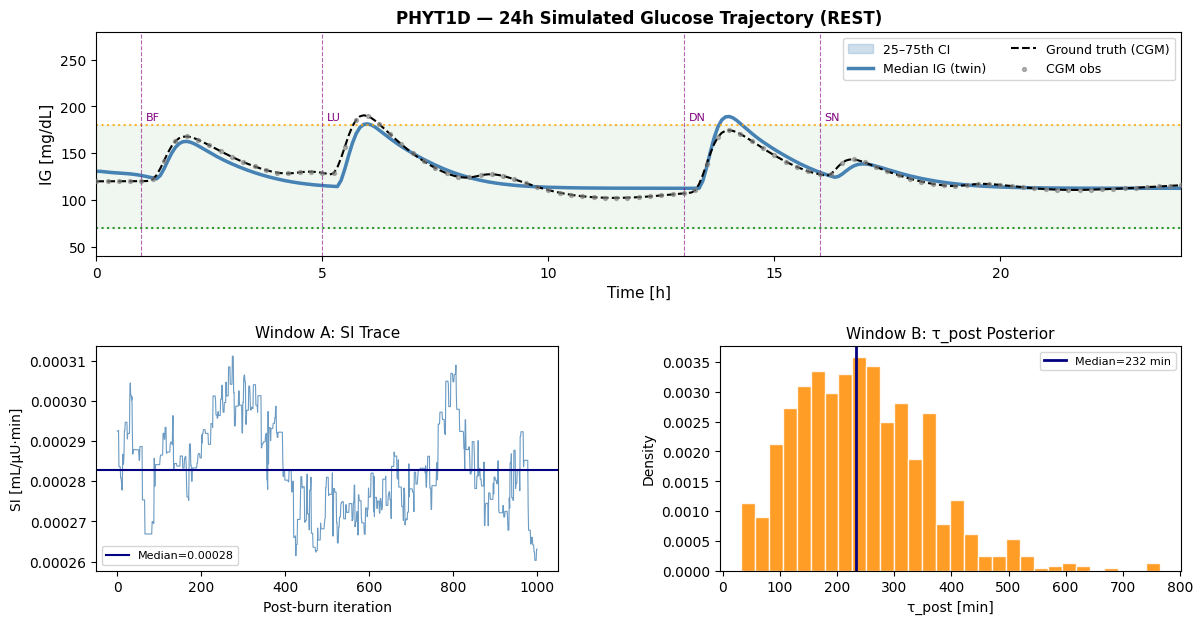


✓ 24h REST trajectory saved.
  MAPE=4.34%  gRMSE=7.07 mg/dL
  TIR=97.6%  TBR=0.0%  TAR=2.4%


In [20]:
fig = plt.figure(figsize=(14, 7))
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.40, wspace=0.35)

# ── Main 24h trajectory ───────────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, :])
ax1.fill_between(times_h, IG_25, IG_75,
                 alpha=0.25, color="steelblue", label="25–75th CI")
ax1.plot(times_h, IG_50,  color="steelblue", lw=2.5, label="Median IG (twin)")
ax1.plot(times_h, ig_true, color="black", lw=1.5, ls="--", label="Ground truth (CGM)")
ax1.scatter(times_true[::3]/60, cgm_obs[::3],
            s=8, color="grey", alpha=0.6, zorder=4, label="CGM obs")

ax1.axhline(70,  color="green",  ls=":", lw=1.5, alpha=0.8)
ax1.axhline(180, color="orange", ls=":", lw=1.5, alpha=0.8)
ax1.fill_between(times_h, 70, 180, alpha=0.06, color="green")

for lbl, t_m in [("BF", USER_PARAMS["t_BF"]), ("LU", USER_PARAMS["t_LU"]),
                  ("DN", USER_PARAMS["t_DN"]), ("SN", USER_PARAMS["t_SN"])]:
    ax1.axvline(t_m/60, color="purple", ls="--", lw=0.8, alpha=0.6)
    ax1.text(t_m/60 + 0.1, 185, lbl, color="purple", fontsize=8)

ax1.set_xlim(0, 24); ax1.set_ylim(40, 280)
ax1.set_xlabel("Time [h]", fontsize=11)
ax1.set_ylabel("IG [mg/dL]", fontsize=11)
ax1.set_title("PHYT1D — 24h Simulated Glucose Trajectory (REST)",
              fontsize=12, fontweight="bold")
ax1.legend(fontsize=9, loc="upper right", ncol=2)

# ── SI trace ──────────────────────────────────────────────────────────────────
ax2 = fig.add_subplot(gs[1, 0])
si_samples = [s["SI"] for s in chain_A]
ax2.plot(si_samples, color="steelblue", lw=0.8, alpha=0.8)
ax2.axhline(np.median(si_samples), color="navy", ls="-", lw=1.5,
            label=f"Median={np.median(si_samples):.5f}")
ax2.set_title("Window A: SI Trace", fontsize=11)
ax2.set_xlabel("Post-burn iteration"); ax2.set_ylabel("SI [mL/μU·min]")
ax2.legend(fontsize=8)

# ── tau_post posterior ────────────────────────────────────────────────────────
ax3 = fig.add_subplot(gs[1, 1])
tp_samples = [s["tau_post"] for s in chain_B]
ax3.hist(tp_samples, bins=30, color="darkorange",
         edgecolor="white", alpha=0.85, density=True)
ax3.axvline(np.median(tp_samples), color="navy", ls="-", lw=2,
            label=f"Median={np.median(tp_samples):.0f} min")
ax3.set_title("Window B: τ_post Posterior", fontsize=11)
ax3.set_xlabel("τ_post [min]"); ax3.set_ylabel("Density")
ax3.legend(fontsize=8)

plt.savefig(r"C:\MY_PROJECTS\Exe_aware_DT\Results\Adult10.png", dpi=150, bbox_inches="tight")
plt.show()
print("\n✓ 24h REST trajectory saved.")

print(f"  MAPE={metrics['MAPE']:.2f}%  gRMSE={metrics['gRMSE']:.2f} mg/dL")
print(f"  TIR={metrics['TIR']:.1f}%  TBR={metrics['TBR']:.1f}%  TAR={metrics['TAR']:.1f}%")